# Transfer Learning con PyTorch

Entrenar CNNs desde cero requiere grandes cantidades de datos y tiempo de cómputo. Gran parte de ese esfuerzo se invierte en aprender filtros de bajo nivel que son útiles para cualquier tarea de visión. Surge entonces una pregunta natural: ¿podemos reutilizar una red entrenada en un dataset y adaptarla a una tarea diferente sin repetir el proceso completo?

Eso es precisamente **transfer learning**: transferimos el conocimiento de un modelo preentrenado (generalmente en **ImageNet**) a nuestra tarea específica. Las capas convolucionales ya saben extraer bordes, texturas y formas genéricas; nosotros solo necesitamos adaptar la cabeza de clasificación.

En este notebook exploraremos tres estrategias:
1. Extracción de features con el backbone congelado
2. Reemplazar el clasificador final y entrenar solo esa parte
3. Fine-tuning: descongelar gradualmente el backbone


## 0. Imports y configuración


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.tensorboard import SummaryWriter
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
from torchinfo import summary
import matplotlib.pyplot as plt
import numpy as np
import os
from PIL import Image
import glob

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Usando device: {device}')


Usando device: cuda


## 1. Funciones auxiliares

Definimos aquí las utilidades que usaremos a lo largo del notebook: verificación del dataset, visualización de muestras, y el loop de entrenamiento con logging a TensorBoard.


In [3]:
def check_image_dir(pattern):
    """Elimina imágenes corruptas que coincidan con el patrón glob."""
    removed = 0
    for fname in glob.glob(pattern):
        try:
            img = Image.open(fname)
            img.verify()
        except Exception:
            print(f'Eliminando archivo corrupto: {fname}')
            os.remove(fname)
            removed += 1
    print(f'{pattern}: {removed} archivos eliminados')


def display_dataset(dataset, n=10):
    """Muestra n imágenes aleatorias del dataset con su etiqueta."""
    indices = np.random.choice(len(dataset), n, replace=False)
    fig, axes = plt.subplots(2, n // 2, figsize=(15, 5))
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    for ax, idx in zip(axes.flat, indices):
        img, label = dataset[idx]
        img = (img * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()
        ax.imshow(img)
        title = dataset.classes[label] if hasattr(dataset, 'classes') else str(label)
        ax.set_title(title, fontsize=9)
        ax.axis('off')
    plt.tight_layout()
    plt.show()


def train_epoch(model, loader, optimizer, loss_fn):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for X, y in loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        out = model(X)
        loss = loss_fn(out, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(y)
        correct += (out.argmax(1) == y).sum().item()
        total += len(y)
    return total_loss / total, correct / total


def eval_epoch(model, loader, loss_fn):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            out = model(X)
            loss = loss_fn(out, y)
            total_loss += loss.item() * len(y)
            correct += (out.argmax(1) == y).sum().item()
            total += len(y)
    return total_loss / total, correct / total


def train(
    model, train_loader, test_loader,
    loss_fn=None, optimizer=None,
    epochs=5, lr=1e-3, writer=None, tag=''
):
    if loss_fn is None:
        loss_fn = nn.CrossEntropyLoss()
    if optimizer is None:
        optimizer = optim.Adam(
            filter(lambda p: p.requires_grad, model.parameters()), lr=lr
        )
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, loss_fn)
        va_loss, va_acc = eval_epoch(model, test_loader, loss_fn)
        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['val_loss'].append(va_loss)
        history['val_acc'].append(va_acc)
        if writer:
            writer.add_scalars(f'{tag}/Loss', {'train': tr_loss, 'val': va_loss}, epoch)
            writer.add_scalars(f'{tag}/Acc',  {'train': tr_acc,  'val': va_acc},  epoch)
        print(f'Epoch {epoch:02d}/{epochs} | '
              f'train loss {tr_loss:.4f} acc {tr_acc:.4f} | '
              f'val loss {va_loss:.4f} acc {va_acc:.4f}')
    return history


def plot_results(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(history['train_loss'], label='train')
    ax1.plot(history['val_loss'],   label='val')
    ax1.set_title('Loss'); ax1.legend()
    ax2.plot(history['train_acc'], label='train')
    ax2.plot(history['val_acc'],   label='val')
    ax2.set_title('Accuracy'); ax2.legend()
    plt.tight_layout()
    plt.show()

print('Funciones auxiliares definidas ✓')


Funciones auxiliares definidas ✓


## 2. Dataset: Cats vs. Dogs

Usaremos el [Kaggle Cats vs. Dogs Dataset](https://www.kaggle.com/c/dogs-vs-cats), también disponible [desde Microsoft](https://www.microsoft.com/en-us/download/details.aspx?id=54765). Es un conjunto clásico de ~25 000 imágenes de gatos y perros, ideal para experimentar con transfer learning porque el dominio (fotografías naturales) coincide con ImageNet.


In [4]:
import zipfile

os.makedirs('data', exist_ok=True)

if not os.path.exists('data/kagglecatsanddogs_5340.zip'):
    !curl https://download.microsoft.com/download/3/E/1/3E1C3F21-ECDB-4869-8368-6DEBA77B919F/kagglecatsanddogs_5340.zip -o data/kagglecatsanddogs_5340.zip

if not os.path.exists('data/PetImages'):
    with zipfile.ZipFile('data/kagglecatsanddogs_5340.zip', 'r') as zip_ref:
        zip_ref.extractall('data')


El dataset contiene algunas imágenes corruptas. Las eliminamos antes de construir el `Dataset`:


In [5]:
check_image_dir('data/PetImages/Cat/*.jpg')
check_image_dir('data/PetImages/Dog/*.jpg')


data/PetImages/Cat/*.jpg: 0 archivos eliminados
data/PetImages/Dog/*.jpg: 0 archivos eliminados


/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/PIL/TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))


### Transforms y normalización

Los modelos preentrenados en ImageNet esperan imágenes de **224 × 224** píxeles normalizadas con la media y desviación estándar del dataset de entrenamiento original:

```
mean = [0.485, 0.456, 0.406]
std  = [0.229, 0.224, 0.225]
```

Usar estos valores es fundamental: si los activamos con distribuciones de entrada distintas, los pesos preentrenados producirán representaciones incorrectas.

> **TODO 1:** Completa el pipeline de transforms. Debe redimensionar a 256, recortar al centro 224 × 224, convertir a tensor y aplicar la normalización.


Total de imágenes: 24998 | Clases: ['Cat', 'Dog']
Train: 20000 | Test: 4998


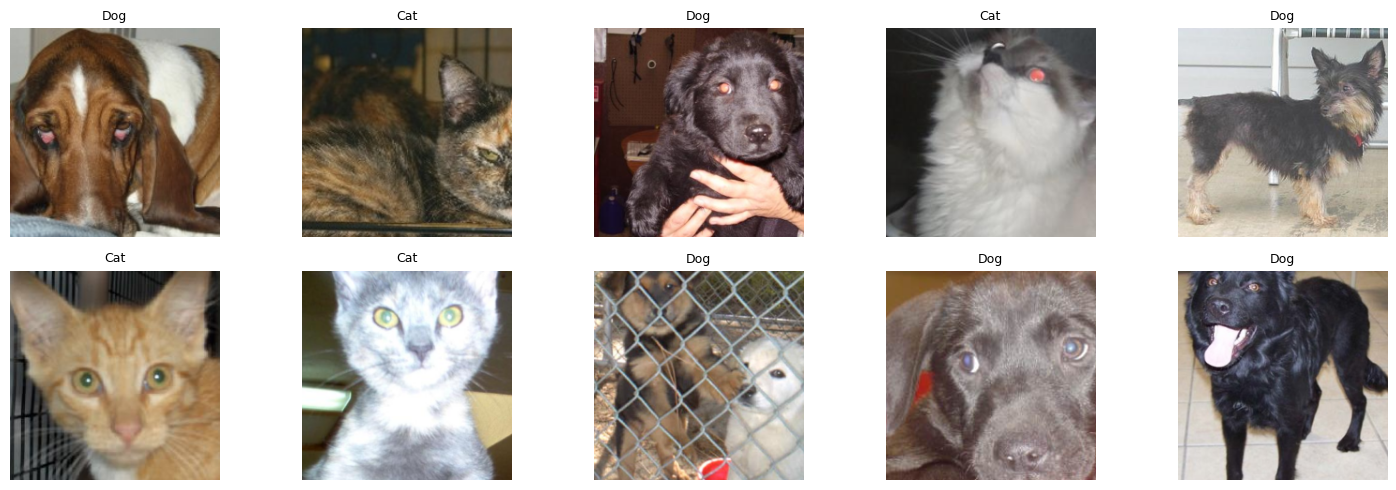

In [6]:
std_normalize = transforms.Normalize(
    mean=[0.485, 0.456, 0.406],
    std =[0.229, 0.224, 0.225]
)

# TODO 1: Define `trans` como un transforms.Compose con los pasos indicados arriba
trans = None

trans = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    std_normalize
])

# --- no modificar desde aquí ---
assert trans is not None, 'Debes definir el pipeline de transforms'
dataset = torchvision.datasets.ImageFolder('data/PetImages', transform=trans)
print(f'Total de imágenes: {len(dataset)} | Clases: {dataset.classes}')

trainset, testset = torch.utils.data.random_split(
    dataset, [20000, len(dataset) - 20000],
    generator=torch.Generator().manual_seed(42)
)
print(f'Train: {len(trainset)} | Test: {len(testset)}')
display_dataset(dataset)


## 3. Modelos preentrenados

`torchvision.models` incluye decenas de arquitecturas con pesos preentrenados en ImageNet. Cargamos VGG-16 y lo usamos directamente para hacer una inferencia sobre una imagen del dataset:


In [7]:
vgg = torchvision.models.vgg16(weights=torchvision.models.VGG16_Weights.DEFAULT)
vgg = vgg.to(device)

sample_image, _ = dataset[0]
sample_image = sample_image.unsqueeze(0).to(device)

with torch.no_grad():
    res = vgg(sample_image)

print(f'Shape de salida: {res.shape}')  # [1, 1000]
print(f'Clase predicha (índice ImageNet): {res[0].argmax().item()}')


Shape de salida: torch.Size([1, 1000])
Clase predicha (índice ImageNet): 282


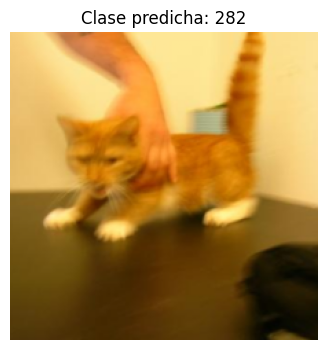

In [8]:
# Visualizar la imagen
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

img_show = (sample_image.squeeze(0).cpu() * std + mean).clamp(0, 1)
img_show = img_show.permute(1, 2, 0).numpy()

plt.figure(figsize=(4, 4))
plt.imshow(img_show)
plt.title(f'Clase predicha: {res[0].argmax().item()}')
plt.axis('off')
plt.show()

La red devuelve un índice de clase de ImageNet. Podemos descargar el mapeo para ver el nombre de la predicción:


In [9]:
import json, requests

class_map = json.loads(
    requests.get('https://s3.amazonaws.com/deep-learning-models/image-models/imagenet_class_index.json').text
)
class_map = {int(k): v for k, v in class_map.items()}

pred_idx = res[0].argmax().item()
print(f'Clase predicha: {class_map[pred_idx]}')


Clase predicha: ['n02123159', 'tiger_cat']


### Arquitectura de VGG-16

Inspeccionemos la arquitectura completa con `torchinfo.summary`. Fíjate en el número total de parámetros y en los tipos de capas que aparecen:


In [10]:
summary(vgg, input_size=(1, 3, 224, 224))

Layer (type:depth-idx)                   Output Shape              Param #
VGG                                      [1, 1000]                 --
├─Sequential: 1-1                        [1, 512, 7, 7]            --
│    └─Conv2d: 2-1                       [1, 64, 224, 224]         1,792
│    └─ReLU: 2-2                         [1, 64, 224, 224]         --
│    └─Conv2d: 2-3                       [1, 64, 224, 224]         36,928
│    └─ReLU: 2-4                         [1, 64, 224, 224]         --
│    └─MaxPool2d: 2-5                    [1, 64, 112, 112]         --
│    └─Conv2d: 2-6                       [1, 128, 112, 112]        73,856
│    └─ReLU: 2-7                         [1, 128, 112, 112]        --
│    └─Conv2d: 2-8                       [1, 128, 112, 112]        147,584
│    └─ReLU: 2-9                         [1, 128, 112, 112]        --
│    └─MaxPool2d: 2-10                   [1, 128, 56, 56]          --
│    └─Conv2d: 2-11                      [1, 256, 56, 56]          29

Además de las capas convolucionales y de pooling que ya conoces, observarás capas **Dropout**. Actúan como técnica de **regularización**: durante el entrenamiento desactivan aleatoriamente una fracción de las neuronas de la capa anterior, lo que obliga a la red a aprender representaciones más robustas y distribuidas.

La arquitectura se divide en tres partes:
- `vgg.features` — el extractor convolucional
- `vgg.avgpool` — pooling adaptativo
- `vgg.classifier` — capas densas que mapean 25 088 features → 1 000 clases

> **Pregunta:** ¿Por qué la última capa tiene exactamente 1 000 salidas?


## 4. Extracción de features

Podemos usar `vgg.features` como extractor fijo: pasamos imágenes, obtenemos tensores de representación, y luego entrenamos un clasificador pequeño encima de esos vectores. Así evitamos reentrenar toda la red.

Primero visualicemos los mapas de activación de la última capa convolucional:


Shape del tensor de features: torch.Size([1, 512, 7, 7])


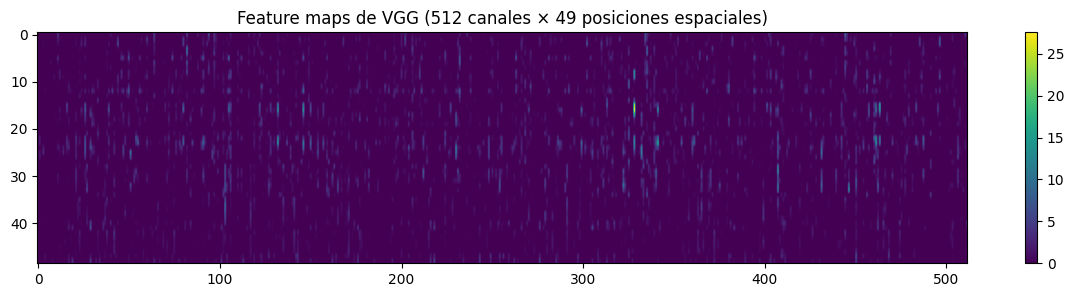

In [11]:
with torch.no_grad():
    feat = vgg.features(sample_image).cpu()

print(f'Shape del tensor de features: {feat.shape}')  # [1, 512, 7, 7]

plt.figure(figsize=(15, 3))
plt.imshow(feat.squeeze().view(512, -1).T, aspect='auto', cmap='viridis')
plt.title('Feature maps de VGG (512 canales × 49 posiciones espaciales)')
plt.colorbar()
plt.show()


Ahora pre-computamos los feature vectors para un subconjunto de 800 imágenes. Almacenamos los resultados en tensores para poder entrenar el clasificador sin recalcular features en cada epoch.

> **TODO 2:** Completa el loop de extracción. Inicializa `feature_tensor` de shape `[num, 512*7*7]` y `label_tensor` de shape `[num]`, luego llena ambos tensores dentro del bucle.


In [12]:
bs  = 8
num = bs * 100  # 800 imágenes
dl  = torch.utils.data.DataLoader(dataset, batch_size=bs, shuffle=True)

# TODO 2: Inicializa feature_tensor y label_tensor
feature_tensor = None  # shape [num, 512*7*7]
label_tensor   = None  # shape [num]

i = 0
for x, l in dl:
    with torch.no_grad():
        # TODO 2 (cont.): extrae features, aplana y almacena en los tensores
        pass
    i += bs
    print('.', end='')
    if i >= num:
        break

print(f'\nfeature_tensor: {feature_tensor.shape} | label_tensor: {label_tensor.shape}')


....................................................................................................

AttributeError: 'NoneType' object has no attribute 'shape'

## 5. Clasificador lineal sobre features fijas

Con los feature vectors pre-computados, entrenamos un clasificador de una sola capa lineal. Esto es extremadamente rápido porque no hay que hacer backprop a través de la CNN.

La función de pérdida estándar para clasificación multiclase en PyTorch es `CrossEntropyLoss`, que internamente aplica softmax. Por eso la red **no debe** incluir una capa de activación final — la red devuelve logits crudos.

> **TODO 3:** Define `net` como un `nn.Sequential` con una sola capa `Linear` de `512*7*7` entradas y `2` salidas.


In [ ]:
vgg_dataset = torch.utils.data.TensorDataset(
    feature_tensor,
    label_tensor.to(torch.long)
)
train_ds, test_ds = torch.utils.data.random_split(vgg_dataset, [700, 100])
train_loader = torch.utils.data.DataLoader(train_ds, batch_size=32)
test_loader  = torch.utils.data.DataLoader(test_ds,  batch_size=32)

# TODO 3: Define net — una Linear(512*7*7, 2) es suficiente con CrossEntropyLoss
net = nn.Sequential
net = net.to(device)

writer  = SummaryWriter('runs/linear_classifier')
history = train(net, train_loader, test_loader, epochs=5, writer=writer, tag='linear')
writer.close()
plot_results(history)


## 6. Transfer learning — Reemplazar el clasificador

En lugar de pre-computar features, podemos conectar directamente nuestra cabeza de clasificación al backbone de VGG y entrenar el modelo end-to-end. Para ello:

1. **Reemplazamos `vgg.classifier`** por una sola capa `Linear(25088, 2)`.
2. **Congelamos `vgg.features`** poniendo `requires_grad = False` en todos sus parámetros.    Esto es importante: si entrenamos end-to-end desde el principio, los errores grandes    del clasificador aleatorio destruirían los pesos preentrenados del extractor.

> **TODO 4:** Carga VGG-16 con pesos preentrenados, reemplaza el clasificador y congela las capas convolucionales.


In [30]:
# TODO 4a: Carga VGG-16 con pesos preentrenados
vgg = vgg = torchvision.models.vgg16(weights=torchvision.models.VGG16_Weights.DEFAULT)
vgg = vgg.to(device)

# TODO 4b: Reemplaza vgg.classifier por Linear(25088, 2)
vgg.classifier = nn.Linear(25088, 2)

# TODO 4c: Congela los parámetros de vgg.features
for param in vgg.features.parameters():
    param.requires_grad = False


# Verifica: solo el clasificador debe tener parámetros entrenables
summary(vgg, input_size=(1, 3, 224, 224))


Layer (type:depth-idx)                   Output Shape              Param #
VGG                                      [1, 2]                    --
├─Sequential: 1-1                        [1, 512, 7, 7]            --
│    └─Conv2d: 2-1                       [1, 64, 224, 224]         (1,792)
│    └─ReLU: 2-2                         [1, 64, 224, 224]         --
│    └─Conv2d: 2-3                       [1, 64, 224, 224]         (36,928)
│    └─ReLU: 2-4                         [1, 64, 224, 224]         --
│    └─MaxPool2d: 2-5                    [1, 64, 112, 112]         --
│    └─Conv2d: 2-6                       [1, 128, 112, 112]        (73,856)
│    └─ReLU: 2-7                         [1, 128, 112, 112]        --
│    └─Conv2d: 2-8                       [1, 128, 112, 112]        (147,584)
│    └─ReLU: 2-9                         [1, 128, 112, 112]        --
│    └─MaxPool2d: 2-10                   [1, 128, 56, 56]          --
│    └─Conv2d: 2-11                      [1, 256, 56, 56]    

El summary debe mostrar aproximadamente **50 000 parámetros entrenables** (solo los pesos de la capa lineal).

Entrenamos con el dataset completo. Este proceso toma bastante tiempo; se recomienda GPU:


/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/PIL/TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Epoch 01/1 | train loss 0.2387 acc 0.9745 | val loss 0.4712 acc 0.9684


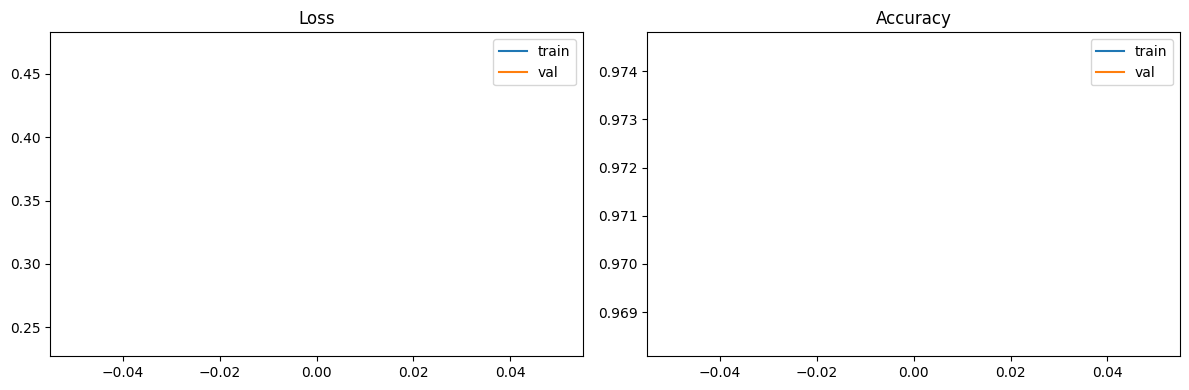

Modelo guardado ✓


In [31]:
trainset, testset = torch.utils.data.random_split(
    dataset, [20000, len(dataset) - 20000],
    generator=torch.Generator().manual_seed(42)
)
train_loader = torch.utils.data.DataLoader(trainset, batch_size=16, num_workers=2, pin_memory=True)
test_loader  = torch.utils.data.DataLoader(testset,  batch_size=16, num_workers=2, pin_memory=True)

writer = SummaryWriter('runs/transfer_frozen')
history_frozen = train(
    vgg, train_loader, test_loader,
    loss_fn=nn.CrossEntropyLoss(),
    epochs=1, lr=1e-3,
    writer=writer, tag='frozen'
)
writer.close()
plot_results(history_frozen)


torch.save(vgg.state_dict(), 'data/cats_dogs_weights.pth')
print('Modelo guardado ✓')



## 7. Fine-tuning — Descongelar el backbone

Una vez que el clasificador tiene pesos razonables, podemos descongelar las capas convolucionales y continuar entrenando toda la red con un **learning rate más pequeño**. Esto permite que el extractor se especialice en nuestro dominio.

> ⚠️ Si descongelamos desde el principio (sin estabilizar primero el clasificador), los gradientes grandes del clasificador aleatorio pueden degradar los pesos preentrenados.

> **TODO 5:** Descongela los parámetros de `vgg.features` y entrena una epoch adicional con `lr=1e-4`.


/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/PIL/TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Epoch 01/1 | train loss 0.1095 acc 0.9644 | val loss 0.0846 acc 0.9650


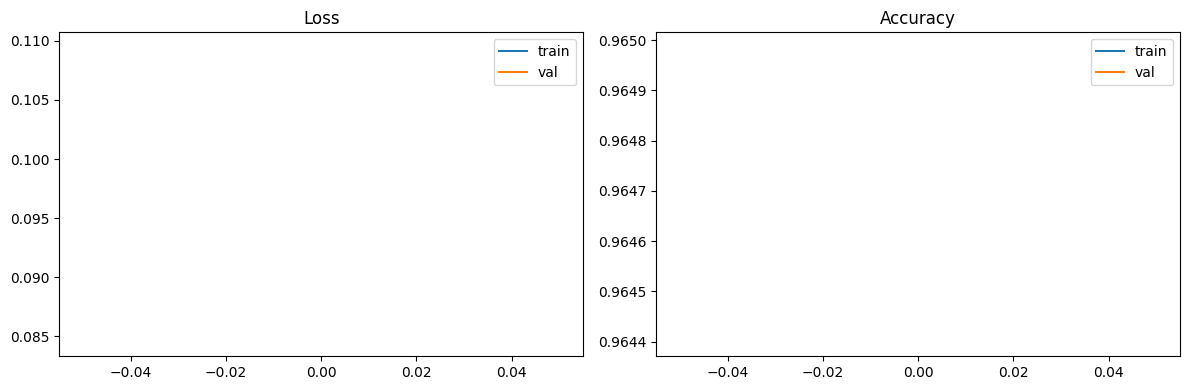

In [33]:
vgg = torchvision.models.vgg16(weights=None)
vgg.classifier = nn.Linear(25088, 2)
vgg.load_state_dict(torch.load('data/cats_dogs_weights.pth', weights_only=True))
vgg = vgg.to(device)

# TODO 5: Descongela vgg.features
for param in vgg.features.parameters():
    param.requires_grad = True

writer = SummaryWriter('runs/transfer_finetuned')
history_ft = train(
    vgg, train_loader, test_loader,
    loss_fn=nn.CrossEntropyLoss(),
    epochs=1, lr=1e-4,
    writer=writer, tag='finetuned'
)
writer.close()
plot_results(history_ft)


## 8. Otras arquitecturas: ResNet

`torchvision.models` incluye muchas más redes preentrenadas. Una de las familias más usadas es **ResNet** (Microsoft Research), que resuelve el problema del gradiente desvaneciente en redes profundas mediante **conexiones residuales** (*skip connections*): cada bloque aprende una corrección a su entrada en lugar de una transformación desde cero.

Exploremos ResNet-18, la versión más ligera de la familia:


In [ ]:
resnet18 = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
print(resnet18)


Observa que la estructura es análoga a VGG: un extractor de features y una capa final de clasificación, aunque aquí se llama `fc` en lugar de `classifier`. También aparecen capas de **Batch Normalization** (`BatchNorm2d`), que normalizan las activaciones dentro de cada minibatch para estabilizar el entrenamiento.

> **TODO 6:** Adapta ResNet-18 para Cats vs. Dogs siguiendo el mismo esquema de la sección 6:
> 1. Congela todos los parámetros.
> 2. Reemplaza `resnet18.fc` por la capa adecuada (investiga cuántas entradas tiene).
> 3. Entrena 2 epochs y compara la velocidad y accuracy con VGG.


In [ ]:
resnet18 = models.resnet18(weights=models.ResNet18_Weights.DEFAULT).to(device)

# TODO 6a: Congela todos los parámetros

# TODO 6b: Reemplaza resnet18.fc
# resnet18.fc = ...

# TODO 6c: Entrena
# writer = SummaryWriter('runs/resnet18')
# history_rn = train(resnet18, train_loader, test_loader, epochs=2, writer=writer, tag='resnet18')
# writer.close()
# plot_results(history_rn)


## 9. Comparación de experimentos con TensorBoard

Todos los experimentos anteriores escribieron logs en el directorio `runs/`. TensorBoard permite comparar curvas de loss y accuracy de todos los experimentos en un mismo panel:


In [ ]:
# En terminal:
#   tensorboard --logdir=runs --port=6006

# En Jupyter / Colab:
%load_ext tensorboard
%tensorboard --logdir runs


## 10. Preguntas de investigación

Responde en celdas Markdown apoyándote en la documentación, papers o experimentos propios.

1. **Normalización ImageNet:** ¿De dónde vienen exactamente los valores `mean=[0.485, 0.456, 0.406]` y `std=[0.229, 0.224, 0.225]`? ¿Qué pasaría si usaras otros valores?

2. **CrossEntropyLoss vs NLLLoss:** Investiga la diferencia entre `nn.CrossEntropyLoss`, `nn.NLLLoss` y `nn.LogSoftmax`. ¿Por qué no debes añadir `LogSoftmax` a la red si ya usas `CrossEntropyLoss`?

3. **Data augmentation:** ¿Qué transforms adicionales añadirías al pipeline de entrenamiento para mejorar la generalización? Impleméntalos y mide el impacto en TensorBoard.

4. **Learning rate scheduling:** Investiga `torch.optim.lr_scheduler.StepLR` y `CosineAnnealingLR`. Agrega uno al loop de fine-tuning y compara las curvas.

5. **Límites del transfer learning:** ¿En qué situaciones transfer learning desde ImageNet podría no ser beneficioso? Da al menos dos ejemplos concretos.

6. **Reto opcional:** Usa `EfficientNet-B0` (disponible en `torchvision.models`) y compara accuracy final y tiempo de entrenamiento contra ResNet-18 y VGG-16.
